# Youth Fellowship Needs Assessment Analysis (2024)

**Organization:** Cherubim and Seraphim Movement Church, Surulere Headquarters — Youth Fellowship (Ayo Ni O)
**Sample:** 652 respondents (634 collected in-person, 18 collected online) from a congregation of approximately 3,500 members
**Method:** Structured questionnaire using a 5-point Likert scale (Strongly Agree = 5, Agree = 4, Undecided = 3, Disagree = 2, Strongly Disagree = 1) plus categorical demographic questions. Benchmark mean for hypothesis testing was set at 3.0.

This notebook recreates and extends the original analysis (originally produced in SPSS and presented as a PowerPoint report to fellowship leadership) using Python. The goal is to demonstrate the same analytical workflow — data structuring, descriptive statistics, visualization, and translating findings into actionable recommendations — in a fully reproducible, code-based format.

**Skills demonstrated:** survey data analysis, pandas data wrangling, data visualization (matplotlib/seaborn), Likert-scale scoring methodology, year-over-year comparative analysis, and stakeholder-facing reporting.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150


## 1. Respondent Demographics

Before analyzing programmatic impact, it's important to understand who responded. Gender and employment/academic status help contextualize the rest of the findings (e.g., a young, largely employed/student population shapes what kinds of interventions are most relevant).

In [2]:
gender = pd.DataFrame({
    'Gender': ['Female', 'Male', 'Blank'],
    'Frequency': [407, 225, 20]
})
gender['Percent'] = (gender['Frequency'] / gender['Frequency'].sum() * 100).round(1)
gender


,Gender,Frequency,Percent
0,Female,407,62.4
1,Male,225,34.5
2,Blank,20,3.1


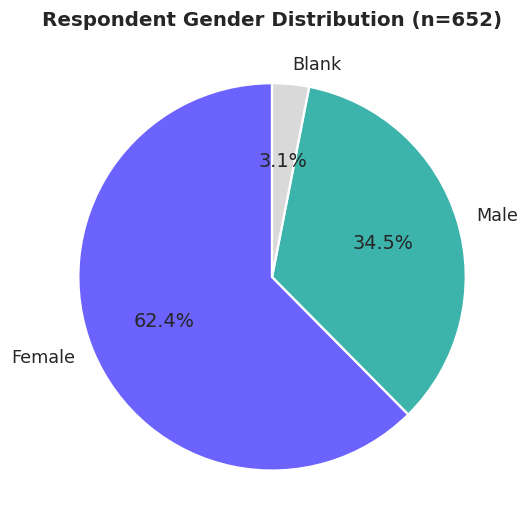

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = ['#6C63FF', '#3CB4AC', '#D9D9D9']
ax.pie(gender['Frequency'], labels=gender['Gender'], autopct='%1.1f%%',
       colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Respondent Gender Distribution (n=652)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/gender_distribution.png', bbox_inches='tight')
plt.show()


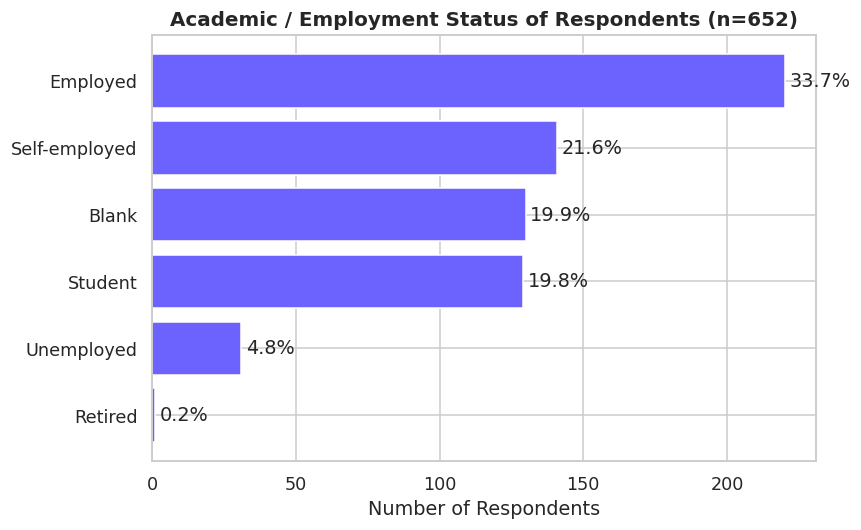

In [4]:
employment = pd.DataFrame({
    'Status': ['Employed', 'Self-employed', 'Student', 'Unemployed', 'Retired', 'Blank'],
    'Frequency': [220, 141, 129, 31, 1, 130]
})
employment['Percent'] = (employment['Frequency'] / employment['Frequency'].sum() * 100).round(1)
employment = employment.sort_values('Frequency', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(employment['Status'], employment['Frequency'], color='#6C63FF')
ax.bar_label(bars, labels=[f"{p}%" for p in employment['Percent']], padding=3)
ax.set_xlabel('Number of Respondents')
ax.set_title('Academic / Employment Status of Respondents (n=652)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/employment_status.png', bbox_inches='tight')
plt.show()


**Insight:** A third of respondents are formally employed and another fifth are self-employed — meaning over half the fellowship's active membership is economically engaged outside school. Combined with the 19.8% who are students, this signals a membership base that spans early-career professionals and students, with very distinct needs (career growth vs. academic support).

## 2. Program Impact — Sunday Services

Members rated how impactful each Sunday service component has been to them personally, on the 5-point Likert scale described above. The mean score for each program reflects overall perceived impact; the benchmark for "impactful" was set at a mean of 3.0.

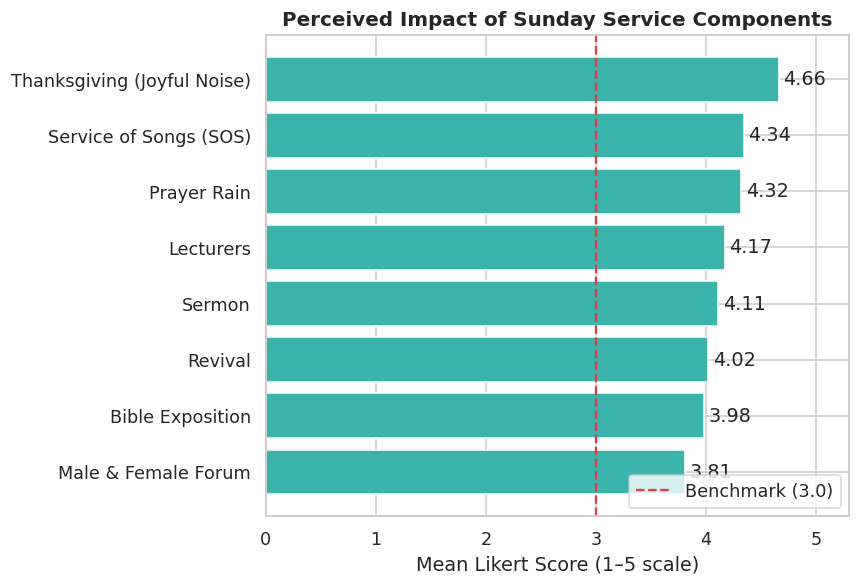

Grand mean across all service types: 4.176
All 8 service components scored well above the 3.0 benchmark — hypothesis that Sunday services are impactful is accepted.


In [5]:
services = pd.DataFrame({
    'Service': ['Thanksgiving (Joyful Noise)', 'Service of Songs (SOS)', 'Prayer Rain', 'Lecturers',
                'Sermon', 'Revival', 'Bible Exposition', 'Male & Female Forum'],
    'N': [632, 606, 602, 626, 627, 608, 570, 551],
    'Mean': [4.66, 4.34, 4.32, 4.17, 4.11, 4.02, 3.98, 3.81]
})
services = services.sort_values('Mean', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(services['Service'], services['Mean'], color='#3CB4AC')
ax.axvline(3.0, color='#E63946', linestyle='--', linewidth=1.5, label='Benchmark (3.0)')
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_xlim(0, 5.3)
ax.set_xlabel('Mean Likert Score (1–5 scale)')
ax.set_title('Perceived Impact of Sunday Service Components', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/service_impact.png', bbox_inches='tight')
plt.show()

print(f"Grand mean across all service types: {services['Mean'].mean():.3f}")
print("All 8 service components scored well above the 3.0 benchmark — hypothesis that Sunday services are impactful is accepted.")


**Insight:** Every program component cleared the 3.0 benchmark, with **Thanksgiving (Joyful Noise)** standing out at 4.66 — the strongest-rated activity in the entire survey. **Male & Female Forum** scored lowest (3.81), still positive but a relative gap worth flagging to leadership as an opportunity area.

## 3. Self-Reported Areas Needing Church Intervention

Beyond rating existing programs, members were asked directly where they need support. This question is arguably the most actionable in the survey — it tells leadership where to direct new resources, not just how existing ones are performing.

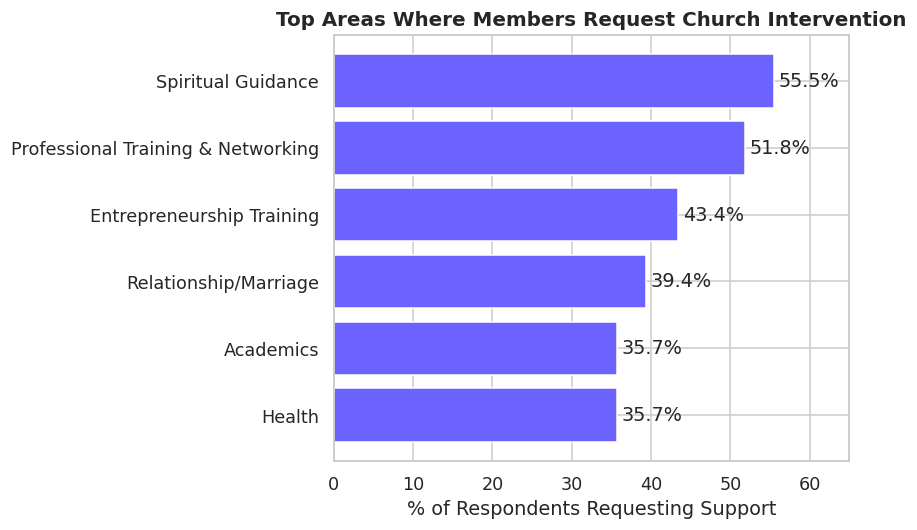

In [6]:
needs = pd.DataFrame({
    'Area': ['Spiritual Guidance', 'Professional Training & Networking', 'Entrepreneurship Training',
             'Relationship/Marriage', 'Academics', 'Health'],
    'Frequency': [362, 338, 283, 257, 233, 233],
    'Percent': [55.5, 51.8, 43.4, 39.4, 35.7, 35.7]
})
needs = needs.sort_values('Percent', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(needs['Area'], needs['Percent'], color='#6C63FF')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_xlabel('% of Respondents Requesting Support')
ax.set_title('Top Areas Where Members Request Church Intervention', fontsize=13, fontweight='bold')
ax.set_xlim(0, 65)
plt.tight_layout()
plt.savefig('outputs/intervention_needs.png', bbox_inches='tight')
plt.show()


**Insight:** Over half of respondents (55.5%) want more **spiritual guidance**, and just over half (51.8%) want **professional training and networking support**. Notably, career-related needs (professional training + entrepreneurship training) combined touch a larger share of members than academics or health — suggesting the fellowship's career-development programming may be under-resourced relative to demand.

## 4. Band / Unit Participation

The fellowship is organized into "bands" (small groups). Understanding band-level participation helps leadership see where engagement is concentrated and where it may need encouragement.

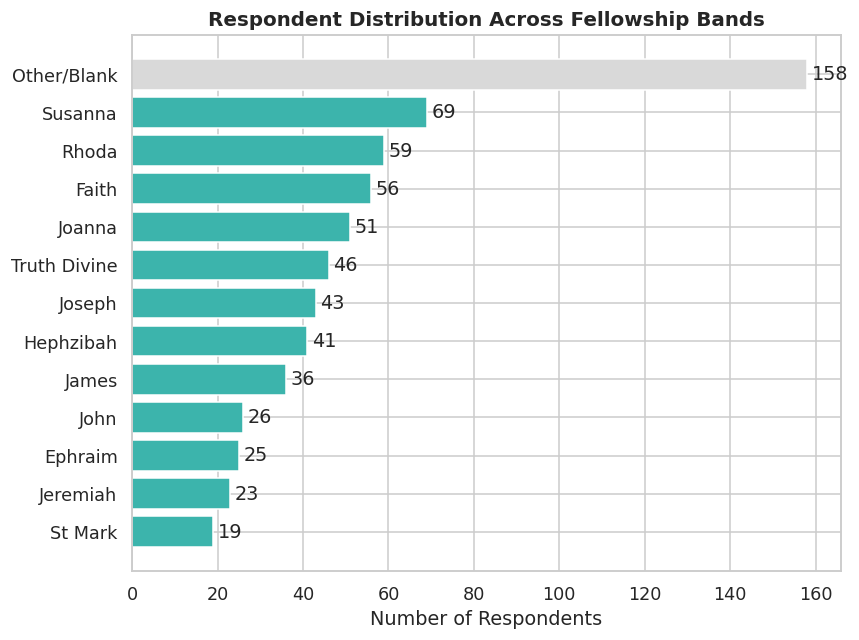

In [7]:
bands = pd.DataFrame({
    'Band': ['Susanna', 'Rhoda', 'Faith', 'Hephzibah', 'James', 'Truth Divine', 'Joanna',
             'Joseph', 'Jeremiah', 'John', 'St Mark', 'Ephraim', 'Other/Blank'],
    'Frequency': [69, 59, 56, 41, 36, 46, 51, 43, 23, 26, 19, 25, 158]
})
bands = bands.sort_values('Frequency', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#D9D9D9' if b == 'Other/Blank' else '#3CB4AC' for b in bands['Band']]
bars = ax.barh(bands['Band'], bands['Frequency'], color=colors)
ax.bar_label(bars, padding=3)
ax.set_xlabel('Number of Respondents')
ax.set_title('Respondent Distribution Across Fellowship Bands', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/band_participation.png', bbox_inches='tight')
plt.show()


## 5. Year-Over-Year Comparison (2022 vs. 2024)

This assessment was also conducted in 2022, allowing for a longitudinal comparison. Tracking whether perceived impact is rising, falling, or holding steady over time is a key signal of whether leadership's program adjustments between cycles are working.

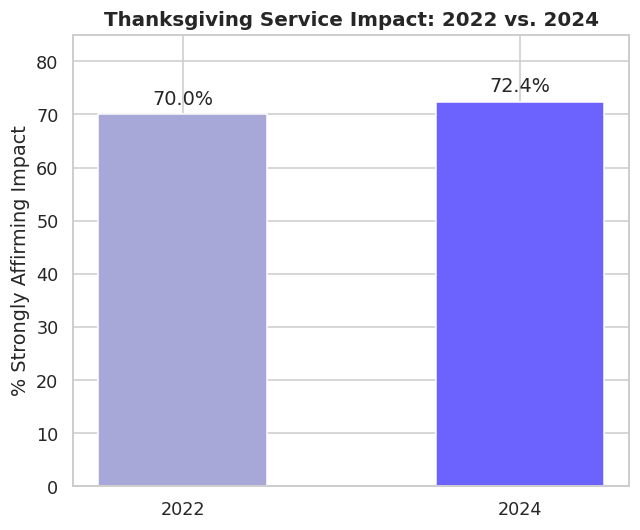

In [8]:
comparison = pd.DataFrame({
    'Year': ['2022', '2024'],
    'Thanksgiving Service - Strongly Affirmed (%)': [70.0, 72.4]
})

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(comparison['Year'], comparison['Thanksgiving Service - Strongly Affirmed (%)'],
              color=['#A8A8D8', '#6C63FF'], width=0.5)
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.set_ylabel('% Strongly Affirming Impact')
ax.set_title('Thanksgiving Service Impact: 2022 vs. 2024', fontsize=13, fontweight='bold')
ax.set_ylim(0, 85)
plt.tight_layout()
plt.savefig('outputs/year_over_year.png', bbox_inches='tight')
plt.show()


**Insight:** The Thanksgiving service maintained strong, slightly improving member sentiment between assessment cycles (70.0% → 72.4% strongly affirming impact), suggesting consistent programming quality over the two-year period.

## 6. Summary of Recommendations to Leadership

Based on the analysis above, the following recommendations were presented to the fellowship's executive committee:

1. **Invest further in career-focused programming.** Professional training/networking (51.8%) and entrepreneurship training (43.4%) are among the top-requested support areas, but currently get less dedicated programming than spiritual content. A structured mentorship or skills workshop series would directly address this gap.
2. **Strengthen the Male & Female Forum.** At a mean impact score of 3.81, it is the lowest-rated (though still positive) program component, suggesting room to improve format or relevance.
3. **Expand spiritual guidance access**, given it is the single most-requested area of support (55.5%) — likely through small-group or one-on-one discipleship structures rather than only large-group sermons.
4. **Use band-level participation data** to identify under-engaged bands (e.g., Ephraim, Jeremiah) for targeted outreach, since band structure appears closely tied to overall fellowship engagement.
5. **Continue the Thanksgiving service format**, given its consistently top-rated, improving impact across both assessment cycles.

---
*Methodology note: this notebook recreates summary-level findings from the original 2024 survey report, which was analyzed in SPSS from 652 raw questionnaire responses. Aggregate frequency/percentage/mean values shown here match the original report; individual-response-level data was not retained for this reconstruction.*
